In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

In [4]:

TRAIN_DIR = "/content/drive/MyDrive/datasets/train"
TEST_DIR = "/content/drive/MyDrive/datasets/test"

IMAGE_SIZE = (128, 128)  # Resize images to 128x128
BATCH_SIZE = 32


In [5]:
# ------------------------------------------------------------
# LOAD TRAIN DATA WITH AUGMENTATION
# ------------------------------------------------------------
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',  # numeric labels
    shuffle=True
)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

classes = list(train_generator.class_indices.keys())
print(f"\nClasses: {classes}")


Found 5757 images belonging to 21 classes.
Found 1640 images belonging to 21 classes.

Classes: ['Grape__black_measles', 'Grape__black_rot', 'Grape__healthy', 'Grape__leaf_blight_(isariopsis_leaf_spot)', 'Lemon__diseased', 'Lemon__healthy', 'Pomegranate__diseased', 'Pomegranate__healthy', 'guava_Disease Free', 'guava_Phytopthora', 'guava_Red rust', 'guava_Scab', 'guava_Styler and Root', 'mango_Anthracnose', 'mango_Bacterial Canker', 'mango_Cutting Weevil', 'mango_Die Back', 'mango_Gall Midge', 'mango_Healthy', 'mango_Powdery Mildew', 'mango_Sooty Mould']


In [6]:
# ------------------------------------------------------------
# LOAD ALL TRAIN IMAGES INTO MEMORY
# ------------------------------------------------------------
def load_data_from_generator(generator):
    X, y = [], []
    steps = len(generator)
    for _ in tqdm(range(steps), desc="Loading data"):
        images, labels = next(generator)  # ✅ use next() instead of generator.next()
        X.append(images)
        y.append(labels)
    X = np.concatenate(X)
    y = np.concatenate(y)
    return X, y


X_train, y_train = load_data_from_generator(train_generator)
X_test, y_test = load_data_from_generator(test_generator)

print(f"\nTrain data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")


Loading data: 100%|██████████| 52/52 [14:47<00:00, 17.07s/it]



Train data shape: (5757, 128, 128, 3)
Test data shape: (1640, 128, 128, 3)


In [7]:
# ------------------------------------------------------------
# PREPROCESSING
# ------------------------------------------------------------
# Flatten images for SVM
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [8]:
# Standardize features
scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)

In [9]:
# ------------------------------------------------------------
# TRAIN CUBIC SVM (POLYNOMIAL DEGREE 3)
# ------------------------------------------------------------
print("\n Training Cubic SVM (kernel='poly', degree=3)...")
svm_cubic = SVC(kernel='poly', degree=3, C=1.0, gamma='scale', probability=True, random_state=42)

svm_cubic.fit(X_train_flat, y_train)


 Training Cubic SVM (kernel='poly', degree=3)...


SVC(kernel='poly', probability=True, random_state=42)

In [10]:
y_pred = svm_cubic.predict(X_test)
acc = accuracy_score(y_test, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print("\n🎯 Test Results (Cubic SVM):")
print(f"Accuracy:  {acc:.4f}")


✅ Test Accuracy: 60.91%

Classification Report:
              precision    recall  f1-score   support

         0.0       0.47      0.99      0.63       277
         1.0       0.86      0.32      0.46       200
         2.0       0.12      0.02      0.04        94
         4.0       0.60      0.19      0.29        16
         5.0       0.67      0.97      0.79        32
         6.0       0.79      0.87      0.83        55
         7.0       0.90      0.76      0.82        58
         8.0       0.67      0.31      0.42        26
         9.0       0.60      0.13      0.21        23
        10.0       0.67      0.22      0.33        18
        11.0       0.68      0.77      0.72        22
        12.0       0.00      0.00      0.00        19
        13.0       0.81      0.60      0.69       100
        14.0       0.59      0.80      0.68       100
        15.0       0.87      0.86      0.86       100
        16.0       0.81      0.69      0.75       100
        17.0       0.55      0.3

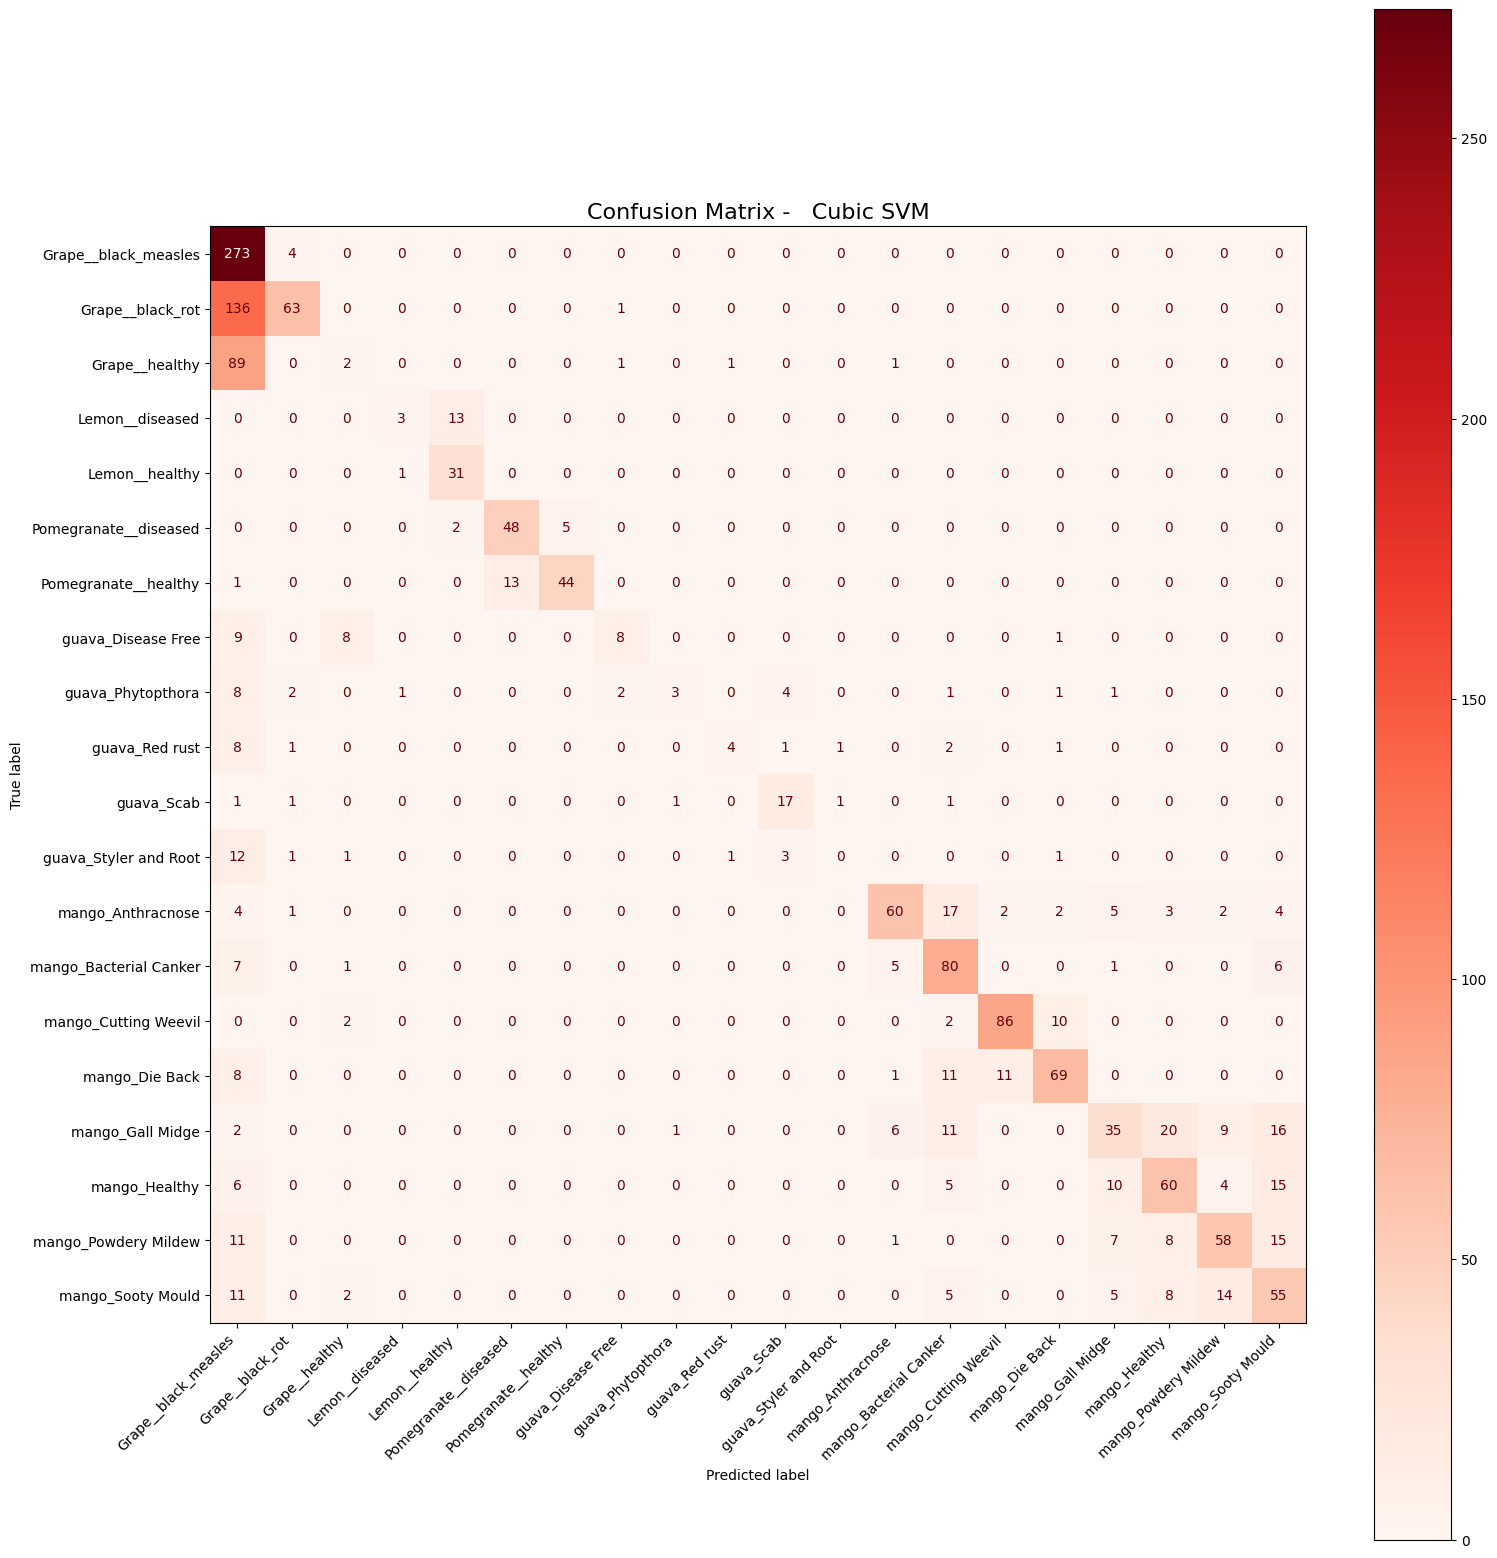

In [15]:
fig, ax = plt.subplots(figsize=(16, 16))  # Make it larger
disp.plot(cmap="Reds", ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix -   Cubic SVM", fontsize=16)
plt.xticks(fontsize=10, rotation=45, ha='right')  # Rotate & align labels
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

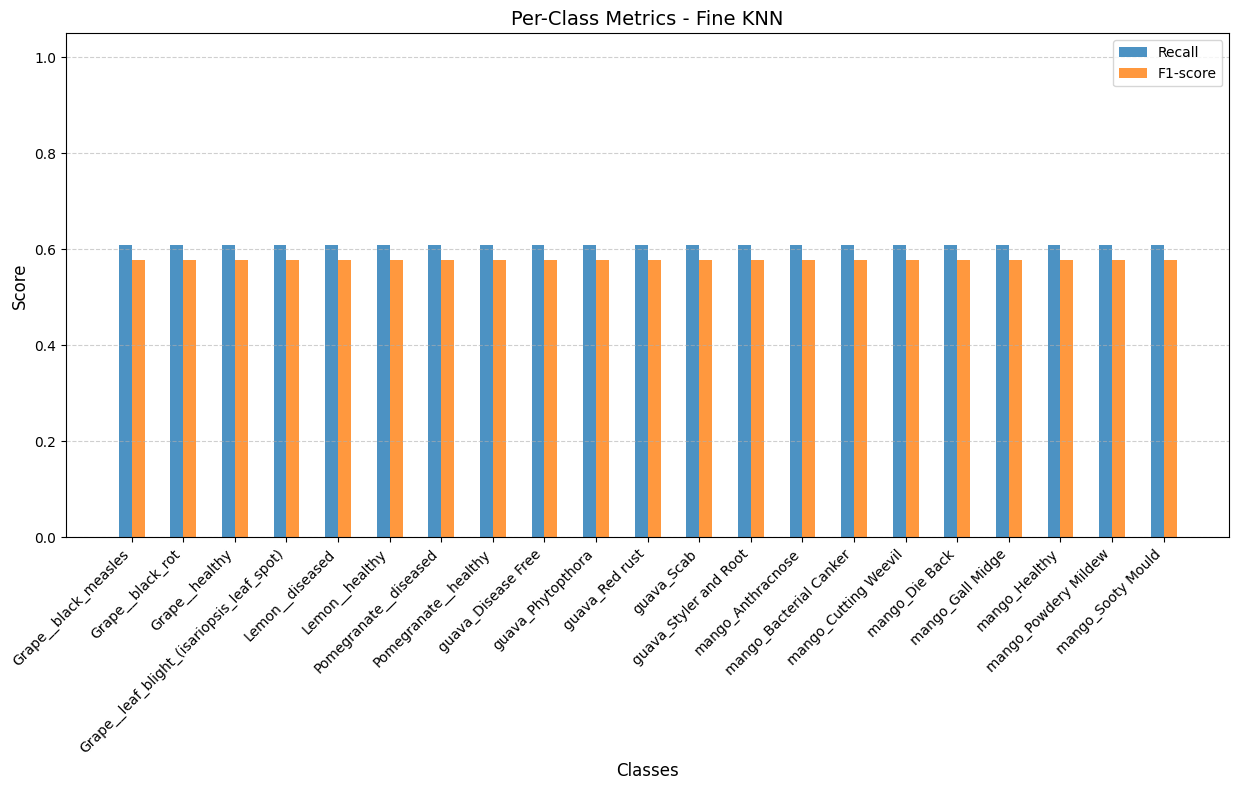

In [25]:
class_names = list(test_generator.class_indices.keys())  # get class names

plt.figure(figsize=(max(10, len(class_names) * 0.6), 8))  # auto-scale width
x = np.arange(len(class_names))
bar_width = 0.25

plt.bar(x, recall, width=bar_width, label='Recall', alpha=0.8)
plt.bar(x + bar_width, f1, width=bar_width, label='F1-score', alpha=0.8)

plt.xticks(x + bar_width / 2, class_names, rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title("Per-Class Metrics - Fine KNN", fontsize=14)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
